Les data pour le Machine Learning, 
collecte et preprocessing

Phase 0 : Récupérer la donnée et l'ouvrir

In [1]:
# télécharger le csv j'utilise le code fourni par Kaggle : 

import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

c:\Users\meddy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\meddy\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [10]:
#Le df ce charge correctement !

import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:

import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Taille du dataset :", df.shape)

Taille du dataset : (7043, 21)


Le dataset se charge correctement, j'ai également vérifié, il n'y a aucune valeur manquant (vide)

Phase 1 : L'audit qualité

In [21]:
# Nous allons déterminé la dimension, types, taux de manquants par colonne et l'équilibre de la cible (churn)

import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df["TotalCharges"].head()
print("Taille du dataset :", df.shape)
print(df["TotalCharges"].head())

Taille du dataset : (7043, 21)
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object


Il y a un problème de typage totalCharges ne devrait pas être un objet 

In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


def audit_qualite(df):
    #rapport de "santé" du DF

    print(f"Forme : {df.shape}")

    print("\nManquants détectés :")

    missing = df.isnull().mean() * 100
    missing = missing.sort_values(ascending=False)
    missing = missing[missing > 0]

    if missing.empty:
        print("0 colonne (méfiance : des trous peuvent être cachés)")
    else:
        for col, val in missing.items():
            print(f"{col} : {val:.2f}%")

    print("\nRépartition de la cible Churn :")

    counts = df["Churn"].value_counts(dropna=False)
    total = len(df)

    for label, count in counts.items():
        pct = (count / total) * 100 if total > 0 else 0
        print(f"Churn {label} : {count} ({pct:.1f}%)")

    print("\nInfos rapides :")
    print(f"Lignes : {len(df)}")
    print(f"Colonnes : {len(df.columns)}")


# 
audit_qualite(df)

Forme : (7043, 21)

Manquants détectés :
0 colonne (méfiance : des trous peuvent être cachés)

Répartition de la cible Churn :
Churn No : 5174 (73.5%)
Churn Yes : 1869 (26.5%)

Infos rapides :
Lignes : 7043
Colonnes : 21


La forme du dataset s'affiche correctement ((7043,21))
Calcul, trie, affichage respecte un comportement correct, aucune colonne n'a de NAN 
La répartition nombre + % nous appercevons un certain déséquilibre (73.5% / 26.5%)

Phase : 2  La colonne piégée (types incohérents et trous cachés)

In [ ]:
import pandas as pd

def reparer_total_charges(df):
    """Convertit TotalCharges en numérique et traite les trous révélés."""

    print("=== Phase 2 : réparation TotalCharges ===")

    # virification du type
    print(f"Type initial : {df['TotalCharges'].dtype}")

    # détection des valeur suspect comme les spaces
    spaces = (df["TotalCharges"] == " ").sum()
    print(f"Valeurs ' ' détectées : {spaces}")

    # conversion en numérique 
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    # NaN créés après conversion
    new_nans = df["TotalCharges"].isna().sum()
    print(f"NaN après conversion : {new_nans}")

    # imputation (médiane = choix standard robuste)
    median = df["TotalCharges"].median()
    df["TotalCharges"] = df["TotalCharges"].fillna(median)

    print(f"Imputation réalisée avec médiane : {median:.2f}")

    # Virification 
    print(f"NaN restants : {df['TotalCharges'].isna().sum()}")

    print("=== Réparation terminée ===")

    return df
df = reparer_total_charges(df)

=== Phase 2 : réparation TotalCharges ===
Type initial : object
Valeurs ' ' détectées : 11
NaN après conversion : 11
Imputation réalisée avec médiane : 1397.47
NaN restants : 0
=== Réparation terminée ===


Nous avons donc convertie Totalcharge en numérique devient float64
compté les NAN 
traité les valeurs manquantes 

Avant la conversion on peut rechercher les valeurs contenant une vigule avec str.contrains. Cela permet de détecter une corruption du format numlérique avant qu'elle ne soit transformé en NAN

Phase 3 :  Encoder les catégorielles


In [ ]:
import pandas as pd

def encoder_features(df):
    """Encode toutes les colonnes catégorielles et renvoie un DataFrame 100% numérique."""

    print("=== Phase 3 : encodage des variables catégorielles ===")

    # Supprimer customerID 
    if "customerID" in df.columns:
        df = df.drop(columns=["customerID"])
        print("customerID supprimée.")

    # Colonnes catégorielles
    cat_cols = df.select_dtypes(include="object").columns

    # Encodage des colonnes yes no
    for col in cat_cols:
        valeurs = set(df[col].dropna().unique())

        if valeurs == {"Yes", "No"}:
            df[col] = df[col].map({"No": 0, "Yes": 1})

    # Rechercher a nouveau les colonnes encore de type object
    remaining_cat = df.select_dtypes(include="object").columns

    # One-Hot Encoding des colonnes nominales restantes
    df = pd.get_dummies(df, columns=remaining_cat, drop_first=True)

    print(f"Nombre de colonnes après encodage : {df.shape[1]}")
    print("Toute les colonnes sont numérique :", all(df.dtypes != "object"))

    return df
df = encoder_features(df)

=== Phase 3 : encodage des variables catégorielles ===
customerID supprimée.
Nombre de colonnes après encodage : 31
Toutes les colonnes sont numériques : True


toutes les variable catégorielles ont été encodée pour obtenir un df entièrement numérique, les binaire ont éte converties en 0/1
Le jeu de donnée est donc prêt pour l'entrainement

Phase 4 : Traiter les valeurs aberrantes


tenure
Borne basse : -60.00
Borne haute : 124.00
Nombre d'outliers : 0

MonthlyCharges
Borne basse : -46.02
Borne haute : 171.38
Nombre d'outliers : 0

TotalCharges
Borne basse : -4674.34
Borne haute : 8863.16
Nombre d'outliers : 0


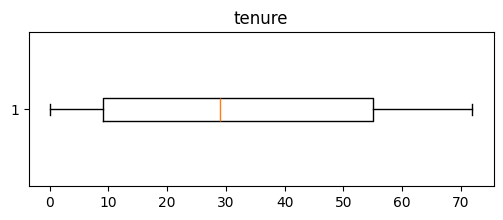

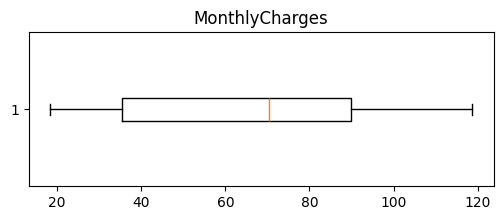

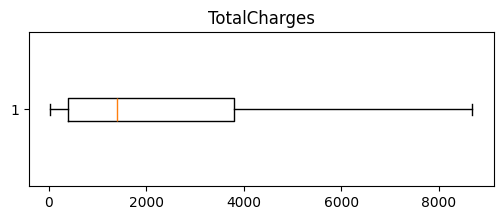

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def detecter_outliers_iqr(df, colonne):
   

    #q1 q3
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # Bornes
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    # Comptage des outliers
    nb_outliers = ((df[colonne] < borne_basse) |
                   (df[colonne] > borne_haute)).sum()

    return borne_basse, borne_haute, nb_outliers

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    bas, haut, nb = detecter_outliers_iqr(df, col)

    print(f"\n{col}")
    print(f"Borne basse : {bas:.2f}")
    print(f"Borne haute : {haut:.2f}")
    print(f"Nombre d'outliers : {nb}")



for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    plt.figure(figsize=(6, 2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

tenure : aucune v aleur abérente, la disposition est propre 
Montlycharges : bornes -46,171 : variable toujours entre 18 et 120 donc ceci indique qu'aucune anomalie n'est présernte 
Total charge : borne -4674;8863 elle sont trés étalé mais aucune valeur hors limite via IQR
Pas d'outlliers détecté

Lanalyse des valeur extrème avec la meme méthode IQR montre qu'aucune des varianle numérique ne contien d'ouliers. Les variable sont considéré commen fiable pour l'entrainement du modèle 